In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [3]:
# Import necessary libraries
import os
import numpy as np
import json
from PIL import Image
from tqdm import tqdm
import shutil
import random
import pandas as pd
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import glob
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Preprocessing

## Load Annotations

In [ ]:
# Function to load and organize COCO annotations

def load_and_organize_annotations(json_path):
    """
    Load COCO format annotations and organize them by image.
    """
    with open(json_path, 'r') as f:
        coco_data = json.load(f)

    image_info = {}
    for img in coco_data['images']:
        image_info[img['id']] = {
            'file_name': img['file_name'],
            'width': img['width'],
            'height': img['height']
        }

    categories = {cat['id']: cat['name'] for cat in coco_data['categories']}

    image_annotations = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        file_name = image_info[img_id]['file_name']
        if file_name not in image_annotations:
            image_annotations[file_name] = []
        annotation = {
            'category_id': ann['category_id'],
            'category_name': categories[ann['category_id']],
            'bbox': ann['bbox'],
            'annotation_id': ann['id']
        }
        image_annotations[file_name].append(annotation)

    return image_annotations, categories, image_info, coco_data

## Tile Extraction

In [ ]:
# Define a function to tile an image into overlapping patches

TILE_WIDTH = 515
TILE_HEIGHT = 512
OVERLAP_RATIO = 0.5

def tile_image(image, tile_width, tile_height, overlap_ratio):
    """
    Tiles an image into overlapping patches.
    """
    img_height, img_width = image.shape[:2]
    step_x = int(tile_width * (1 - overlap_ratio))
    step_y = int(tile_height * (1 - overlap_ratio))

    tiles = []
    for y in range(0, img_height, step_y):
        if y + tile_height > img_height:
            y = img_height - tile_height
        for x in range(0, img_width, step_x):
            if x + tile_width > img_width:
                x = img_width - tile_width
            tile = image[y:y+tile_height, x:x+tile_width]
            tiles.append((tile, x, y, x+tile_width, y+tile_height))
    return tiles

## Generate YOLO Annotations

In [ ]:
def convert_bbox_to_yolo(bbox, tile_x, tile_y, tile_w, tile_h):
    """
    Converts an absolute bbox to YOLO format relative to the tile.
    Clips bbox to stay inside the tile boundaries.
    """
    x_min, y_min, w, h = bbox
    x_max = x_min + w
    y_max = y_min + h

    # Clip bbox to tile boundaries
    x_min_tile = max(x_min, tile_x)
    y_min_tile = max(y_min, tile_y)
    x_max_tile = min(x_max, tile_x + tile_w)
    y_max_tile = min(y_max, tile_y + tile_h)

    # Calculate width and height
    w_tile = x_max_tile - x_min_tile
    h_tile = y_max_tile - y_min_tile

    # Skip tiny boxes
    if w_tile <= 0 or h_tile <= 0:
        return None

    # Calculate bbox center in tile coordinates
    bbox_x_center_tile = (x_min_tile + x_max_tile) / 2 - tile_x
    bbox_y_center_tile = (y_min_tile + y_max_tile) / 2 - tile_y

    # Normalize to [0,1]
    x_center_norm = bbox_x_center_tile / tile_w
    y_center_norm = bbox_y_center_tile / tile_h
    w_norm = w_tile / tile_w
    h_norm = h_tile / tile_h

    # Final sanity check
    if not (0 <= x_center_norm <= 1 and 0 <= y_center_norm <= 1 and 0 <= w_norm <= 1 and 0 <= h_norm <= 1):
        return None

    return x_center_norm, y_center_norm, w_norm, h_norm

## Select First 25% Images Per Cancer Type

In [ ]:
# Select the first 25% of each cancer type except melanoma

def get_image_ids_to_preprocess(coco_data):
    cancer_ranges = [
        ((1, 150), "breast_cancer"),
        ((151, 194), "lung_carcinoma"),
        ((195, 249), "lymphoma"),
        ((250, 299), "mast_cell_tumor"),
        ((300, 354), "neuroendocrine_tumor")
    ]

    selected_image_ids = []

    for (start, end), cancer in cancer_ranges:
        ids = [img['id'] for img in coco_data['images'] if start <= img['id'] <= end]
        ids.sort()
        n_select = max(1, int(0.25 * len(ids)))  # At least 1 image
        selected_image_ids.extend(ids[:n_select])

    return selected_image_ids

## Main Function

In [ ]:
def preprocess_selected_tiles(base_dir, annotations_json, output_dir, selected_image_ids):
    os.makedirs(os.path.join(output_dir, "images"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "labels"), exist_ok=True)

    image_annotations, categories, image_info, _ = load_and_organize_annotations(annotations_json)

    for file_name, annotations in tqdm(image_annotations.items(), desc="Processing Selected Images"):
        img_id = next((id for id, info in image_info.items() if info['file_name'] == file_name), None)
        if img_id is None or img_id not in selected_image_ids:
            continue

        img_path = os.path.join(base_dir, file_name)
        try:
            img = np.array(Image.open(img_path))
        except FileNotFoundError:
            print(f"Image not found: {img_path}")
            continue

        tiles = tile_image(img, TILE_WIDTH, TILE_HEIGHT, OVERLAP_RATIO)

        for idx, (tile, x, y, x_end, y_end) in enumerate(tiles):
            tile_h, tile_w = tile.shape[:2]

            tile_filename = f"{os.path.splitext(file_name)[0]}_{idx}.png"
            tile_path = os.path.join(output_dir, "images", tile_filename)
            Image.fromarray(tile).save(tile_path)

            yolo_annotations = []
            for ann in annotations:
                if ann['category_name'] == 'mitotic figure':
                    class_id = 0
                elif ann['category_name'] == 'not mitotic figure':
                    class_id = 1
                else:
                    continue

                yolo_bbox = convert_bbox_to_yolo(ann['bbox'], x, y, tile_w, tile_h)
                if yolo_bbox is not None:
                    yolo_line = f"{class_id} {yolo_bbox[0]} {yolo_bbox[1]} {yolo_bbox[2]} {yolo_bbox[3]}"
                    yolo_annotations.append(yolo_line)

            label_filename = f"{os.path.splitext(file_name)[0]}_{idx}.txt"
            label_path = os.path.join(output_dir, "labels", label_filename)
            with open(label_path, 'w') as f:
                f.write('\n'.join(yolo_annotations))


In [ ]:
# Run the preprocessing pipeline

base_dir = '/content/drive/MyDrive/MIDOG_Challenge_2022_png'
annotations_json = os.path.join(base_dir, 'MIDOG2022_training_png.json')
output_dir = '/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles'

# Load annotations once to get the COCO data
with open(annotations_json, 'r') as f:
    coco_data = json.load(f)

# Get selected image IDs
selected_image_ids = get_image_ids_to_preprocess(coco_data)
print(f"Selected {len(selected_image_ids)} image IDs to preprocess.")

# Run the preprocessing
preprocess_selected_tiles(base_dir, annotations_json, output_dir, selected_image_ids)

Selected 86 image IDs to preprocess.


Processing Selected Images: 100%|██████████| 354/354 [2:29:10<00:00, 25.28s/it]   


**A validation script to double-check the YOLO label files before training, ensuring that the labels are properly formatted and within the expected [0, 1] range**

In [ ]:
def validate_yolo_labels(labels_dir, image_dir, verbose=True):
    """
    Validates YOLO label files to ensure they are in correct format and within bounds [0,1].

    Args:
        labels_dir (str): Path to the directory containing YOLO label files.
        image_dir (str): Path to the corresponding images directory (to compare image size if needed).
        verbose (bool): Whether to print detailed logs.

    Returns:
        summary (dict): Summary statistics of the validation.
    """
    label_files = glob.glob(os.path.join(labels_dir, '*.txt'))
    errors = 0
    total_labels = 0

    for label_file in label_files:
        with open(label_file, 'r') as f:
            lines = f.readlines()

        for idx, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) != 5:
                print(f"❌ Invalid format in {label_file}, line {idx+1}: '{line.strip()}'")
                errors += 1
                continue

            class_id, x_center, y_center, width, height = parts

            try:
                x_center = float(x_center)
                y_center = float(y_center)
                width = float(width)
                height = float(height)
            except ValueError:
                print(f"❌ Non-numeric values in {label_file}, line {idx+1}: '{line.strip()}'")
                errors += 1
                continue

            # Check if values are within bounds [0,1]
            if not (0 <= x_center <= 1 and 0 <= y_center <= 1 and 0 <= width <= 1 and 0 <= height <= 1):
                print(f"⚠️ Out-of-bounds values in {label_file}, line {idx+1}: {x_center}, {y_center}, {width}, {height}")
                errors += 1

            total_labels += 1

    summary = {
        'Total label files': len(label_files),
        'Total labels checked': total_labels,
        'Errors found': errors,
    }

    if verbose:
        print("\n🔍 Validation Summary:")
        for key, value in summary.items():
            print(f"  {key}: {value}")
        if errors == 0:
            print("✅ All labels are valid!")
        else:
            print("⚠️ Some labels have errors. Please review and fix them before training.")

    return summary

labels_dir = '/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/labels'
images_dir = '/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images'
validate_yolo_labels(labels_dir, images_dir)


🔍 Validation Summary:
  Total label files: 50308
  Total labels checked: 342695
  Errors found: 0
✅ All labels are valid!


{'Total label files': 50308, 'Total labels checked': 342695, 'Errors found': 0}

**Script to analyze the class distribution after preprocessing**

In [ ]:
def analyze_class_distribution(labels_dir):
    """
    Analyzes the class distribution in YOLO label files.

    Args:
        labels_dir (str): Directory containing YOLO label files.

    Returns:
        Counter object with counts of each class.
    """
    class_counts = Counter()

    label_files = glob.glob(os.path.join(labels_dir, '*.txt'))
    total_files = len(label_files)

    for label_file in label_files:
        with open(label_file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 1:
                    class_id = parts[0]
                    class_counts[class_id] += 1

    print(f"📊 Class distribution after tiling and preprocessing:")
    for class_id, count in class_counts.items():
        print(f"  Class {class_id}: {count} instances")

    print(f"\n🔍 Total label files: {total_files}")
    print(f"⚠️ Note: Some label files may contain multiple annotations.")

    return class_counts

labels_dir = '/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/labels'
analyze_class_distribution(labels_dir)

📊 Class distribution after tiling and preprocessing:
  Class 1: 180247 instances
  Class 0: 162448 instances

🔍 Total label files: 50308
⚠️ Note: Some label files may contain multiple annotations.


Counter({'1': 180247, '0': 162448})

# Multi --> Multi

## Data Preperation

### Group Tiles by Image ID

In [5]:
# Group tiles by image ID

def group_tiles_by_image_id(tile_dir):
    """
    Groups tiles by their parent image ID, tile filenames are like: 001_0.png, 001_1.png, etc.
    """
    tiles = os.listdir(tile_dir)
    image_groups = defaultdict(list)

    for tile in tiles:
        if tile.endswith('.png'):
            img_id = tile.split('_')[0]  # e.g. '001'
            image_groups[img_id].append(tile)

    return image_groups

### Create Stratification Keys

In [4]:
# Use the annotations JSON to map image_id to cancer_type

def get_image_id_to_cancer_type(coco_data):
    """
    Returns a dict mapping image_id (as str) to cancer_type.
    """
    mapping = {}
    for img in coco_data['images']:
        img_id = str(img['id']).zfill(3)  # Match '001', '002', etc.
        id_num = img['id']
        if 1 <= id_num <= 150:
            cancer = 'breast_cancer'
        elif 151 <= id_num <= 194:
            cancer = 'lung_carcinoma'
        elif 195 <= id_num <= 249:
            cancer = 'lymphoma'
        elif 250 <= id_num <= 299:
            cancer = 'mast_cell_tumor'
        elif 300 <= id_num <= 354:
            cancer = 'neuroendocrine_tumor'
        else:
            cancer = 'melanoma'  # We'll skip these later
        mapping[img_id] = cancer
    return mapping


### Split Images into Train/Val/Test

In [ ]:
def split_multi_multi(image_groups, id_to_cancer, output_base, test_size=0.15, val_ratio=0.10):
    """
    Splits images into train/val/test folders, stratified by cancer type.
    """
    # Filter out melanoma
    valid_image_ids = [img_id for img_id, cancer in id_to_cancer.items() if cancer != 'melanoma' and img_id in image_groups]

    # Organize by cancer type
    cancer_to_images = defaultdict(list)
    for img_id in valid_image_ids:
        cancer_to_images[id_to_cancer[img_id]].append(img_id)

    train_ids, val_ids, test_ids = [], [], []

    for cancer, ids in cancer_to_images.items():
        random.shuffle(ids)
        n_total = len(ids)
        n_test = max(1, int(test_size * n_total))
        n_trainval = n_total - n_test
        n_val = max(1, int(val_ratio * n_trainval))
        n_train = n_trainval - n_val

        test_ids.extend(ids[:n_test])
        val_ids.extend(ids[n_test:n_test + n_val])
        train_ids.extend(ids[n_test + n_val:])

    print(f"Train images: {len(train_ids)}")
    print(f"Val images: {len(val_ids)}")
    print(f"Test images: {len(test_ids)}")

    # Move tiles and labels into split folders
    for split, split_ids in zip(['train', 'val', 'test'], [train_ids, val_ids, test_ids]):
        for folder in ['images', 'labels']:
            os.makedirs(os.path.join(output_base, folder, split), exist_ok=True)

        for img_id in split_ids:
            for tile_name in image_groups[img_id]:
                # Move image
                src_img = os.path.join(output_base, 'images', tile_name)
                dst_img = os.path.join(output_base, 'images', split, tile_name)
                shutil.copy2(src_img, dst_img)

                # Move label
                label_name = tile_name.replace('.png', '.txt')
                src_label = os.path.join(output_base, 'labels', label_name)
                dst_label = os.path.join(output_base, 'labels', split, label_name)
                if os.path.exists(src_label):
                    shutil.copy2(src_label, dst_label)

### Create data.yaml

In [6]:
def write_yolo_data_yaml(output_base):
    """
    Creates a data.yaml file for YOLOv8 training with 2 classes.
    """
    yaml_content = f"""
path: {output_base}
train: images/train
val: images/val
test: images/test

nc: 2
names: ['mitotic_figure', 'non_mitotic_figure']
    """.strip()

    yaml_path = os.path.join(output_base, 'data.yaml')
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)
    print(f"data.yaml written to {yaml_path}")

### Main Code

In [ ]:
output_base = '/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles'

# Load the COCO data
with open(os.path.join(base_dir, 'MIDOG2022_training_png.json'), 'r') as f:
    coco_data = json.load(f)

# Group tiles
image_groups = group_tiles_by_image_id(os.path.join(output_base, 'images'))

# Map image ID to cancer type
id_to_cancer = get_image_id_to_cancer_type(coco_data)

# Split data
split_multi_multi(image_groups, id_to_cancer, output_base)

# Write data.yaml
write_yolo_data_yaml(output_base)

Train images: 70
Val images: 7
Test images: 9
data.yaml written to /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/data.yaml


**Verify Splits**

In [ ]:
# Verify the number of images in each split
base_split_dir = '/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images'

train_count = len(os.listdir(os.path.join(base_split_dir, 'train')))
val_count = len(os.listdir(os.path.join(base_split_dir, 'val')))
test_count = len(os.listdir(os.path.join(base_split_dir, 'test')))

print(f"Train images: {train_count}")
print(f"Validation images: {val_count}")
print(f"Test images: {test_count}")

Train images: 40860
Validation images: 4086
Test images: 5362


**Check mitotic vs. non-mitotic ratio in each split**

In [7]:
def count_classes_in_split(labels_dir):
    """
    Counts the number of mitotic and non-mitotic instances in a YOLO labels directory.
    """
    class_counts = Counter()

    for label_file in os.listdir(labels_dir):
        if label_file.endswith('.txt'):
            with open(os.path.join(labels_dir, label_file), 'r') as f:
                lines = f.readlines()
                for line in lines:
                    class_id = line.strip().split()[0]  # first element is class id
                    class_counts[class_id] += 1

    return class_counts

In [ ]:
# Print class distribution in each split
splits = ['train', 'val', 'test']
labels_base_dir = '/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/labels'

for split in splits:
    split_labels_dir = os.path.join(labels_base_dir, split)
    counts = count_classes_in_split(split_labels_dir)
    print(f"📊 {split.capitalize()} Split Class Distribution:")
    for cls_id, count in counts.items():
        label_name = "Mitotic" if cls_id == "1" else "Non-Mitotic"
        print(f"  {label_name} (Class {cls_id}): {count} instances")
    print("-" * 40)

**Display a random training image**

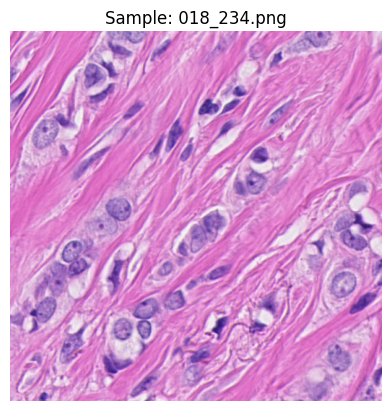

In [ ]:
# Display a random training image
import random
from PIL import Image
import matplotlib.pyplot as plt

sample_dir = os.path.join(base_split_dir, 'train')
sample_image = random.choice(os.listdir(sample_dir))
sample_path = os.path.join(sample_dir, sample_image)

img = Image.open(sample_path)
plt.imshow(img)
plt.title(f"Sample: {sample_image}")
plt.axis('off')
plt.show()

## Train YOLOv8n

In [ ]:
# Train YOLOv8n with selected hyperparameters
!yolo train \
  model=yolov8n.pt \
  data=/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/data.yaml \
  epochs=30 \
  imgsz=512 \
  batch=8 \
  optimizer=SGD \
  lr0=0.01 \
  momentum=0.937 \
  weight_decay=0.0005

Görüntülenen çıkış son 5000 satıra kısaltıldı.
train: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/train/253_433.png: 24 duplicate labels removed
train: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/train/253_434.png: 29 duplicate labels removed
train: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/train/253_435.png: 34 duplicate labels removed
train: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/train/253_436.png: 36 duplicate labels removed
train: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/train/253_437.png: 35 duplicate labels removed
train: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/train/253_438.png: 38 duplicate labels removed
train: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/train/253_439.png: 39 duplicate labels removed
train: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/train/253_440.png: 39 duplicate labels removed
t

## Evaluate on Validation and Test Sets

In [8]:
def print_and_plot_confusion_matrix(results_json, split_name=''):
    """
    Loads YOLOv8 evaluation results from results.json and prints key metrics
    (Precision, Recall, F1, mAP50, mAP50-95, Accuracy) along with a confusion matrix heatmap.
    """
    if not os.path.exists(results_json):
        print(f"No results.json found at {results_json}.")
        return

    with open(results_json, 'r') as f:
        results = json.load(f)

    # Extract metrics
    def safe_get(metric):
        val = results.get(metric, 0.0)
        if isinstance(val, list):
            return val[0]
        else:
            return val

    mp = safe_get('metrics/precision(B)')
    mr = safe_get('metrics/recall(B)')
    map50 = safe_get('metrics/mAP50(B)')
    map5095 = safe_get('metrics/mAP50-95(B)')

    f1 = (2 * mp * mr) / (mp + mr + 1e-8)

    print(f"📊 {split_name} Set Metrics:")
    print(f"  Precision: {mp:.4f}")
    print(f"  Recall:    {mr:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  mAP@50:    {map50:.4f}")
    print(f"  mAP@50-95: {map5095:.4f}")

    # Confusion matrix
    confusion_matrix = results.get('confusion_matrix')
    if confusion_matrix:
        cm = np.array(confusion_matrix)

        # Truncate to 2x2 (mitotic and non-mitotic only)
        if cm.shape[0] > 2 and cm.shape[1] > 2:
            cm = cm[:2, :2]

        labels = ['Non-Mitotic', 'Mitotic']

        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
            total = cm.sum()
            accuracy = (tp + tn) / total if total > 0 else 0.0
            print(f"  Accuracy:  {accuracy:.4f}")
        else:
            print(f"⚠️ Confusion matrix shape unexpected after truncation: {cm.shape}")

        print("\nConfusion Matrix (raw values):")
        print(cm)

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=labels + [f'Extra {i}' for i in range(cm.shape[1] - 2)],
                    yticklabels=labels + [f'Extra {i}' for i in range(cm.shape[0] - 2)])
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'{split_name} Set Confusion Matrix')
        plt.show()
    else:
        print("\nConfusion Matrix not available.")

Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 234.6±91.3 MB/s, size: 539.0 KB)


val: Scanning /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/labels/val.cache... 4086 images, 539 backgrounds, 0 corrupt: 100%|██████████| 4086/4086 [00:00<?, ?it/s]

val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/val/023_414.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/val/023_415.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/val/023_440.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/val/023_441.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/val/023_443.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/val/023_444.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/val/023_469.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/val/023_470.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/val/023_472.png: 1


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 256/256 [00:47<00:00,  5.40it/s]


                   all       4086      20141      0.437      0.306      0.302      0.214
        mitotic_figure       2990      10532      0.457      0.315      0.305      0.215
    non_mitotic_figure       2990       9609      0.418      0.297        0.3      0.213
Speed: 0.2ms preprocess, 1.0ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/val15
Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
val: Fast image access ✅ (ping: 0.3±0.0 ms, read: 167.0±127.0 MB/s, size: 490.4 KB)


val: Scanning /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/labels/test.cache... 5362 images, 1297 backgrounds, 0 corrupt: 100%|██████████| 5362/5362 [00:00<?, ?it/s]

val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/test/002_308.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/test/002_309.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/test/002_310.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/test/002_311.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/test/002_312.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/test/002_313.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/test/002_314.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/test/002_315.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/images/test/002_3


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 336/336 [00:59<00:00,  5.66it/s]


                   all       5362      14025       0.41      0.409      0.305      0.218
        mitotic_figure       3126       5583      0.386      0.433      0.297      0.222
    non_mitotic_figure       3225       8442      0.434      0.385      0.313      0.213
Speed: 0.2ms preprocess, 1.0ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val16
📊 Validation Set Metrics:
  Precision: 0.4372
  Recall:    0.3062
  F1-score:  0.3602
  mAP@50:    0.3024
  mAP@50-95: 0.2145
  Accuracy:  0.4945

Confusion Matrix (raw values):
[[       1133        1313]
 [        427         569]]


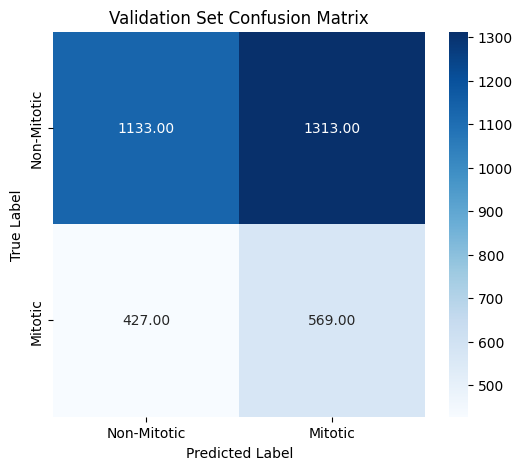

📊 Test Set Metrics:
  Precision: 0.4104
  Recall:    0.4094
  F1-score:  0.4099
  mAP@50:    0.3050
  mAP@50-95: 0.2175
  Accuracy:  0.4970

Confusion Matrix (raw values):
[[        522         968]
 [        466         895]]


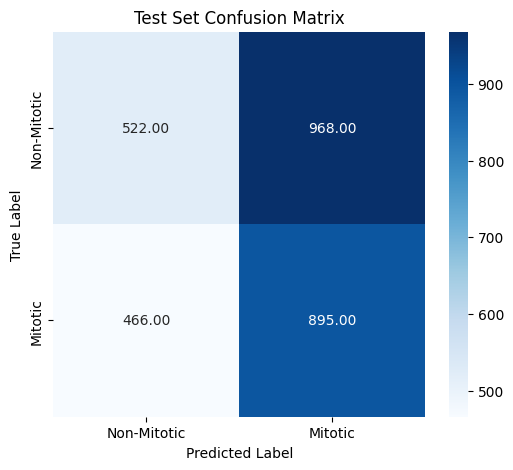

In [ ]:
# Evaluate on validation set
metrics_val = model.val(
    data='/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/data.yaml',
    split='val'
)

# Evaluate on test set
metrics_test = model.val(
    data='/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles/data.yaml',
    split='test'
)

# Function to serialize DetMetrics object
def serialize_metrics(metrics):
    serialized = {
        'metrics/precision(B)': metrics.box.mp.tolist() if hasattr(metrics.box.mp, 'tolist') else [float(metrics.box.mp)],
        'metrics/recall(B)': metrics.box.mr.tolist() if hasattr(metrics.box.mr, 'tolist') else [float(metrics.box.mr)],
        'metrics/mAP50(B)': metrics.box.map50.tolist() if hasattr(metrics.box.map50, 'tolist') else [float(metrics.box.map50)],
        'metrics/mAP50-95(B)': metrics.box.map.tolist() if hasattr(metrics.box.map, 'tolist') else [float(metrics.box.map)],
        'confusion_matrix': metrics.confusion_matrix.matrix.tolist() if metrics.confusion_matrix is not None else None
    }
    return serialized

# Save JSON results
os.makedirs('/content/runs/detect/val_eval', exist_ok=True)
os.makedirs('/content/runs/detect/test_eval', exist_ok=True)

with open('/content/runs/detect/val_eval/results.json', 'w') as f:
    json.dump(serialize_metrics(metrics_val), f)

with open('/content/runs/detect/test_eval/results.json', 'w') as f:
    json.dump(serialize_metrics(metrics_test), f)

# Print and plot confusion matrix
print_and_plot_confusion_matrix('/content/runs/detect/val_eval/results.json', split_name='Validation')
print_and_plot_confusion_matrix('/content/runs/detect/test_eval/results.json', split_name='Test')

## Visualize Training Loss and Validation Metrics

Columns found in results.csv: Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


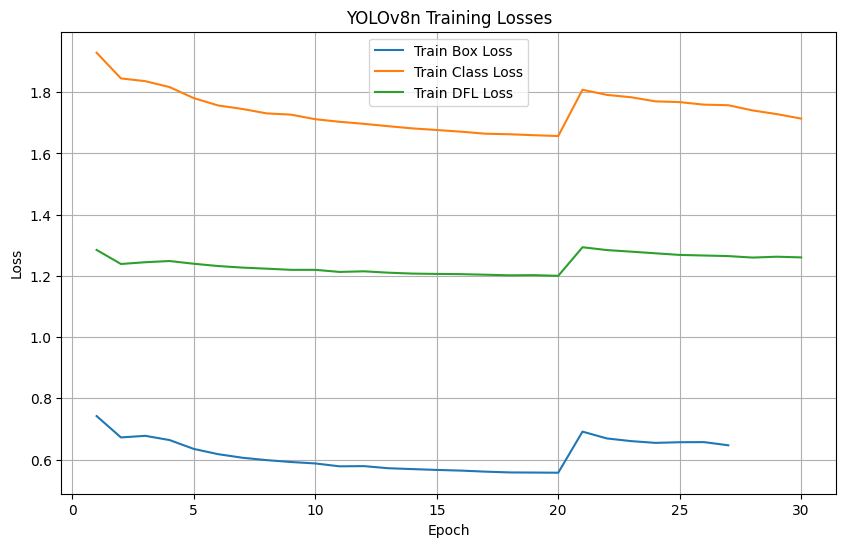

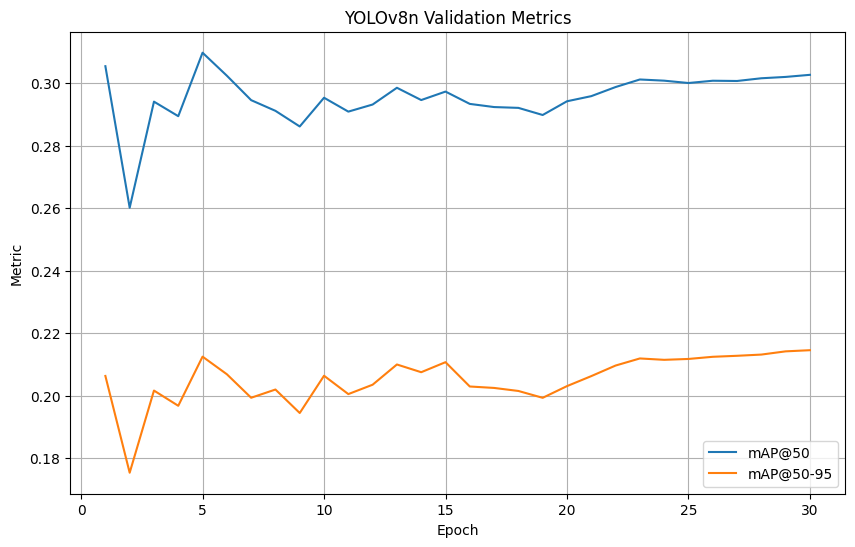

In [ ]:
# Path to YOLO training logs
results_csv = '/content/runs/detect/train3/results.csv'

# Load the results.csv
results_df = pd.read_csv(results_csv)
print("Columns found in results.csv:", results_df.columns)

# Plot training loss curves
plt.figure(figsize=(10, 6))
plt.plot(results_df['epoch'], results_df['train/box_loss'], label='Train Box Loss')
plt.plot(results_df['epoch'], results_df['train/cls_loss'], label='Train Class Loss')
plt.plot(results_df['epoch'], results_df['train/dfl_loss'], label='Train DFL Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('YOLOv8n Training Losses')
plt.legend()
plt.grid(True)
plt.show()

# Plot validation metrics
plt.figure(figsize=(10, 6))
plt.plot(results_df['epoch'], results_df['metrics/mAP50(B)'], label='mAP@50')
plt.plot(results_df['epoch'], results_df['metrics/mAP50-95(B)'], label='mAP@50-95')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.title('YOLOv8n Validation Metrics')
plt.legend()
plt.grid(True)
plt.show()

# Multi --> Breast

### Data Preparation

In [ ]:
def split_multi_breast(image_groups, id_to_cancer, output_base, val_ratio=0.10):
    """
    Splits images into train/val/test folders.
    Train and val from non-breast cancers.
    Test set from breast cancer only.
    """
    # Filter image IDs
    trainval_ids = [img_id for img_id, cancer in id_to_cancer.items()
                    if cancer != 'melanoma' and cancer != 'breast_cancer' and img_id in image_groups]
    test_ids = [img_id for img_id, cancer in id_to_cancer.items()
                if cancer == 'breast_cancer' and img_id in image_groups]

    # Stratify train/val by cancer type
    cancer_to_images = defaultdict(list)
    for img_id in trainval_ids:
        cancer_to_images[id_to_cancer[img_id]].append(img_id)

    train_ids, val_ids = [], []

    for cancer, ids in cancer_to_images.items():
        random.shuffle(ids)
        n_total = len(ids)
        n_val = max(1, int(val_ratio * n_total))
        n_train = n_total - n_val

        val_ids.extend(ids[:n_val])
        train_ids.extend(ids[n_val:])

    print(f"Train images: {len(train_ids)}")
    print(f"Val images: {len(val_ids)}")
    print(f"Test images (Breast): {len(test_ids)}")

    # Move tiles and labels
    for split, split_ids in zip(['train', 'val', 'test'], [train_ids, val_ids, test_ids]):
        for folder in ['images', 'labels']:
            os.makedirs(os.path.join(output_base, folder, split), exist_ok=True)
        for img_id in split_ids:
            for tile_name in image_groups[img_id]:
                src_img = os.path.join(base_dir, 'all_tiles/images', tile_name)
                dst_img = os.path.join(output_base, 'images', split, tile_name)
                shutil.copy2(src_img, dst_img)

                label_name = tile_name.replace('.png', '.txt')
                src_label = os.path.join(base_dir, 'all_tiles/labels', label_name)
                dst_label = os.path.join(output_base, 'labels', split, label_name)
                if os.path.exists(src_label):
                    shutil.copy2(src_label, dst_label)

In [ ]:
# Setup paths
output_base_breast = '/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast'
os.makedirs(output_base_breast, exist_ok=True)
base_dir = '/content/drive/MyDrive/MIDOG_Challenge_2022_png'

# Load COCO annotations
with open(os.path.join(base_dir, 'MIDOG2022_training_png.json'), 'r') as f:
    coco_data = json.load(f)

# Group tiles and map cancer type
image_groups_breast = group_tiles_by_image_id(os.path.join(base_dir, 'all_tiles/images'))
id_to_cancer_breast = get_image_id_to_cancer_type(coco_data)

# Split data
split_multi_breast(image_groups_breast, id_to_cancer_breast, output_base_breast)

# Write data.yaml
write_yolo_data_yaml(output_base_breast)

print("✅ Multi → Breast data splitting and setup complete.")

# Check split counts
splits = ['train', 'val', 'test']
labels_base_dir_breast = os.path.join(output_base_breast, 'labels')
for split in splits:
    split_labels_dir = os.path.join(labels_base_dir_breast, split)
    counts = count_classes_in_split(split_labels_dir)
    print(f"📊 {split.capitalize()} Split Class Distribution:")
    for cls_id, count in counts.items():
        label_name = "Mitotic" if cls_id == "1" else "Non-Mitotic"
        print(f"  {label_name} (Class {cls_id}): {count} instances")
    print("-" * 40)

print("✅ Data prepared for Multi → Breast pipeline.")

Train images: 45
Val images: 4
Test images (Breast): 37
data.yaml written to /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/data.yaml
✅ Multi → Breast data splitting and setup complete.
📊 Train Split Class Distribution:
  Non-Mitotic (Class 0): 131824 instances
  Mitotic (Class 1): 123611 instances
----------------------------------------
📊 Val Split Class Distribution:
  Non-Mitotic (Class 0): 4843 instances
  Mitotic (Class 1): 18172 instances
----------------------------------------
📊 Test Split Class Distribution:
  Mitotic (Class 1): 38463 instances
  Non-Mitotic (Class 0): 25776 instances
----------------------------------------
✅ Data prepared for Multi → Breast pipeline.


## Train YOLOv8n

In [ ]:
# Train YOLOv8n with selected hyperparameters
!yolo train \
  model=yolov8n.pt \
  data=/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/data.yaml \
  epochs=30 \
  imgsz=512 \
  batch=8 \
  optimizer=SGD \
  lr0=0.01 \
  momentum=0.937 \
  weight_decay=0.0005

Görüntülenen çıkış son 5000 satıra kısaltıldı.
train: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/train/251_439.png: 50 duplicate labels removed
train: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/train/251_440.png: 51 duplicate labels removed
train: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/train/251_441.png: 51 duplicate labels removed
train: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/train/251_445.png: 1 duplicate labels removed
train: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/train/251_446.png: 2 duplicate labels removed
train: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/train/251_447.png: 7 duplicate labels removed
train: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/train/251_448.png: 7 duplicate labels removed
train: /cont

## Evaluate on Validation and Test Sets

Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.0 ms, read: 243.6±75.2 MB/s, size: 569.7 KB)


val: Scanning /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/labels/val.cache... 2172 images, 104 backgrounds, 0 corrupt: 100%|██████████| 2172/2172 [00:00<?, ?it/s]

val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/val/154_119.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/val/154_120.png: 2 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/val/154_121.png: 2 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/val/154_122.png: 2 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/val/154_123.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/val/154_124.png: 2 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/val/154_125.png: 3 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/val/


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 136/136 [00:29<00:00,  4.65it/s]


                   all       2172      15815      0.419      0.366      0.341       0.23
        mitotic_figure       1496       4007      0.342      0.472      0.357      0.252
    non_mitotic_figure       1805      11808      0.496      0.259      0.325      0.209
Speed: 0.2ms preprocess, 1.0ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/val
Ultralytics 8.3.146 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
val: Fast image access ✅ (ping: 0.4±0.0 ms, read: 0.9±0.2 MB/s, size: 534.2 KB)


val: Scanning /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/labels/test... 23606 images, 7162 backgrounds, 0 corrupt: 100%|██████████| 23606/23606 [25:43<00:00, 15.29it/s]

val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/test/002_308.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/test/002_309.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/test/002_310.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/test/002_311.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/test/002_312.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/test/002_313.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/images/test/002_314.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/imag

val: New cache created: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/labels/test.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1476/1476 [01:53<00:00, 13.04it/s]


                   all      23606      51217        0.4      0.362      0.238      0.174
        mitotic_figure      11061      20821      0.366      0.371      0.225      0.163
    non_mitotic_figure      13800      30396      0.434      0.353      0.251      0.184
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val2
📊 Validation Set Metrics:
  Precision: 0.4189
  Recall:    0.3659
  F1-score:  0.3906
  mAP@50:    0.3407
  mAP@50-95: 0.2303
  Accuracy:  0.4535

Confusion Matrix (raw values):
[[        657        1153]
 [        417         646]]


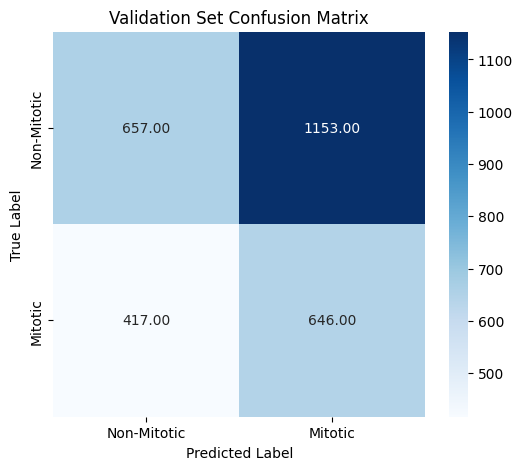

📊 Test Set Metrics:
  Precision: 0.3999
  Recall:    0.3617
  F1-score:  0.3799
  mAP@50:    0.2376
  mAP@50-95: 0.1737
  Accuracy:  0.4983

Confusion Matrix (raw values):
[[       2754        4706]
 [       2566        4470]]


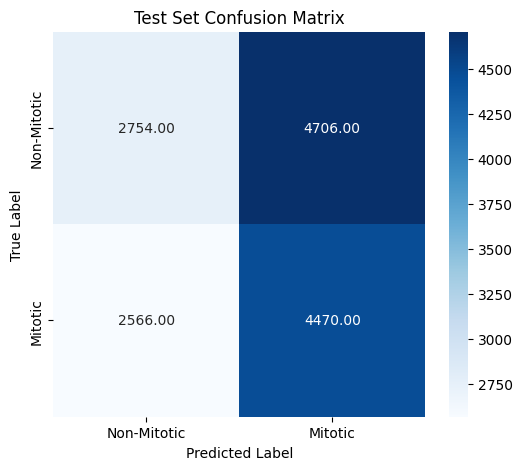

In [ ]:
# Load the trained model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Evaluate on validation set
metrics_val = model.val(
    data='/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/data.yaml',
    split='val'
)

# Evaluate on test set
metrics_test = model.val(
    data='/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_multi_to_breast/data.yaml',
    split='test'
)

# Function to serialize DetMetrics object
def serialize_metrics(metrics):
    serialized = {
        'metrics/precision(B)': metrics.box.mp.tolist() if hasattr(metrics.box.mp, 'tolist') else [float(metrics.box.mp)],
        'metrics/recall(B)': metrics.box.mr.tolist() if hasattr(metrics.box.mr, 'tolist') else [float(metrics.box.mr)],
        'metrics/mAP50(B)': metrics.box.map50.tolist() if hasattr(metrics.box.map50, 'tolist') else [float(metrics.box.map50)],
        'metrics/mAP50-95(B)': metrics.box.map.tolist() if hasattr(metrics.box.map, 'tolist') else [float(metrics.box.map)],
        'confusion_matrix': metrics.confusion_matrix.matrix.tolist() if metrics.confusion_matrix is not None else None
    }
    return serialized

# Save JSON results
os.makedirs('/content/runs/detect/val_eval_multi_to_breast', exist_ok=True)
os.makedirs('/content/runs/detect/test_eval_multi_to_breast', exist_ok=True)

with open('/content/runs/detect/val_eval_multi_to_breast/results.json', 'w') as f:
    json.dump(serialize_metrics(metrics_val), f)

with open('/content/runs/detect/test_eval_multi_to_breast/results.json', 'w') as f:
    json.dump(serialize_metrics(metrics_test), f)

# Print and plot confusion matrix
print_and_plot_confusion_matrix('/content/runs/detect/val_eval_multi_to_breast/results.json', split_name='Validation')
print_and_plot_confusion_matrix('/content/runs/detect/test_eval_multi_to_breast/results.json', split_name='Test')

## Visualize Training Loss and Validation Metrics

Columns found in results.csv: Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


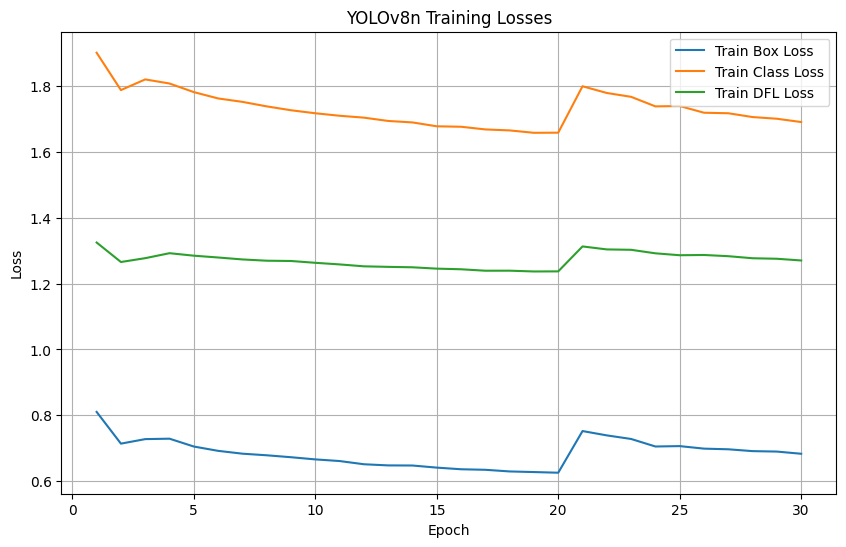

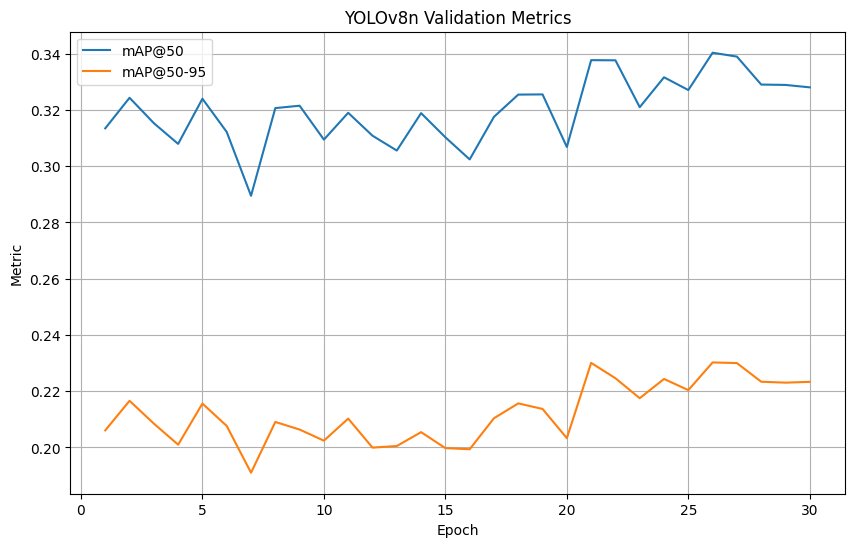

In [ ]:
# Path to YOLO training logs
results_csv = '/content/runs/detect/train/results.csv'

# Load the results.csv
results_df = pd.read_csv(results_csv)
print("Columns found in results.csv:", results_df.columns)

# Plot training loss curves
plt.figure(figsize=(10, 6))
plt.plot(results_df['epoch'], results_df['train/box_loss'], label='Train Box Loss')
plt.plot(results_df['epoch'], results_df['train/cls_loss'], label='Train Class Loss')
plt.plot(results_df['epoch'], results_df['train/dfl_loss'], label='Train DFL Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('YOLOv8n Training Losses')
plt.legend()
plt.grid(True)
plt.show()

# Plot validation metrics
plt.figure(figsize=(10, 6))
plt.plot(results_df['epoch'], results_df['metrics/mAP50(B)'], label='mAP@50')
plt.plot(results_df['epoch'], results_df['metrics/mAP50-95(B)'], label='mAP@50-95')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.title('YOLOv8n Validation Metrics')
plt.legend()
plt.grid(True)
plt.show()

# Breast --> Multi

### Data Preparation

In [ ]:
def split_breast_multi(image_groups, id_to_cancer, output_base, val_ratio=0.10):
    """
    Splits images into train/val/test folders.
    Train and val from breast cancer.
    Test set from non-breast cancers.
    """
    # Filter image IDs
    trainval_ids = [img_id for img_id, cancer in id_to_cancer.items()
                    if cancer != 'melanoma' and cancer == 'breast_cancer' and img_id in image_groups]
    test_ids = [img_id for img_id, cancer in id_to_cancer.items()
                if cancer != 'melanoma' and cancer != 'breast_cancer' and img_id in image_groups]

    # Stratify train/val by breast cancer
    cancer_to_images = defaultdict(list)
    for img_id in trainval_ids:
        cancer_to_images[id_to_cancer[img_id]].append(img_id)

    train_ids, val_ids = [], []

    for cancer, ids in cancer_to_images.items():
        random.shuffle(ids)
        n_total = len(ids)
        n_val = max(1, int(val_ratio * n_total))
        n_train = n_total - n_val

        val_ids.extend(ids[:n_val])
        train_ids.extend(ids[n_val:])

    print(f"Train images (Breast): {len(train_ids)}")
    print(f"Val images (Breast): {len(val_ids)}")
    print(f"Test images (Multi): {len(test_ids)}")

    # Move tiles and labels
    for split, split_ids in zip(['train', 'val', 'test'], [train_ids, val_ids, test_ids]):
        for folder in ['images', 'labels']:
            os.makedirs(os.path.join(output_base, folder, split), exist_ok=True)
        for img_id in split_ids:
            for tile_name in image_groups[img_id]:
                src_img = os.path.join(base_dir, 'all_tiles/images', tile_name)
                dst_img = os.path.join(output_base, 'images', split, tile_name)
                shutil.copy2(src_img, dst_img)

                label_name = tile_name.replace('.png', '.txt')
                src_label = os.path.join(base_dir, 'all_tiles/labels', label_name)
                dst_label = os.path.join(output_base, 'labels', split, label_name)
                if os.path.exists(src_label):
                    shutil.copy2(src_label, dst_label)

In [ ]:
# Setup paths
output_base_breast_to_multi = '/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi'
os.makedirs(output_base_breast_to_multi, exist_ok=True)
base_dir = '/content/drive/MyDrive/MIDOG_Challenge_2022_png'

# Load COCO annotations
with open(os.path.join(base_dir, 'MIDOG2022_training_png.json'), 'r') as f:
    coco_data = json.load(f)

# Group tiles and map cancer type
image_groups_breast_to_multi = group_tiles_by_image_id(os.path.join(base_dir, 'all_tiles/images'))
id_to_cancer_breast_to_multi = get_image_id_to_cancer_type(coco_data)

# Split data
split_breast_multi(image_groups_breast_to_multi, id_to_cancer_breast_to_multi, output_base_breast_to_multi)

# Write data.yaml
write_yolo_data_yaml(output_base_breast_to_multi)

print("✅ Breast → Multi data splitting and setup complete.")

Train images (Breast): 34
Val images (Breast): 3
Test images (Multi): 49
data.yaml written to /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/data.yaml
✅ Breast → Multi data splitting and setup complete.


In [9]:
# Check split counts
splits = ['train', 'val', 'test']
labels_base_dir_breast_to_multi = os.path.join(output_base_breast_to_multi, 'labels')
for split in splits:
    split_labels_dir = os.path.join(labels_base_dir_breast_to_multi, split)
    counts = count_classes_in_split(split_labels_dir)
    print(f"📊 {split.capitalize()} Split Class Distribution:")
    for cls_id, count in counts.items():
        label_name = "Mitotic" if cls_id == "1" else "Non-Mitotic"
        print(f"  {label_name} (Class {cls_id}): {count} instances")
    print("-" * 40)

print("✅ Data prepared for Breast → Multi pipeline.")

📊 Train Split Class Distribution:
  Mitotic (Class 1): 35892 instances
  Non-Mitotic (Class 0): 24962 instances
----------------------------------------
📊 Val Split Class Distribution:
  Non-Mitotic (Class 0): 814 instances
  Mitotic (Class 1): 2571 instances
----------------------------------------
📊 Test Split Class Distribution:
  Mitotic (Class 1): 141784 instances
  Non-Mitotic (Class 0): 136672 instances
----------------------------------------
✅ Data prepared for Breast → Multi pipeline.


## Train YOLOv8n

In [4]:
# Train YOLOv8n with selected hyperparameters
!yolo train \
  model=yolov8n.pt \
  data=/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/data.yaml \
  epochs=30 \
  imgsz=512 \
  batch=8 \
  optimizer=SGD \
  lr0=0.01 \
  momentum=0.937 \
  weight_decay=0.0005

100% 6.25M/6.25M [00:00<00:00, 397MB/s]
Ultralytics 8.3.147 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, opti

## Evaluate on Validation and Test Sets

Ultralytics 8.3.147 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.0 ms, read: 69.1±27.4 MB/s, size: 501.6 KB)


val: Scanning /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/labels/val.cache... 1914 images, 562 backgrounds, 0 corrupt: 100%|██████████| 1914/1914 [00:00<?, ?it/s]

val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/images/val/005_432.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/images/val/005_433.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/images/val/005_434.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/images/val/005_461.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/images/val/005_462.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/images/val/005_463.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/images/val/005_490.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/images/val/


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 120/120 [00:22<00:00,  5.43it/s]


                   all       1914       2996      0.372      0.447      0.296      0.217
        mitotic_figure        649        796      0.255       0.57      0.267      0.193
    non_mitotic_figure       1182       2200      0.488      0.324      0.325       0.24
Speed: 0.2ms preprocess, 1.0ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/val5
Ultralytics 8.3.147 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA L4, 22693MiB)
val: Fast image access ✅ (ping: 0.3±0.0 ms, read: 204.7±121.9 MB/s, size: 598.2 KB)


val: Scanning /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/labels/test.cache... 26694 images, 2732 backgrounds, 0 corrupt: 100%|██████████| 26702/26702 [00:00<?, ?it/s]

val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/images/test/151_125.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/images/test/151_126.png: 2 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/images/test/151_127.png: 2 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/images/test/151_128.png: 2 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/images/test/151_129.png: 2 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/images/test/151_143.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/images/test/151_152.png: 1 duplicate labels removed
val: /content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/imag


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1669/1669 [05:38<00:00,  4.93it/s]


                   all      26702     198438      0.381      0.242      0.253      0.172
        mitotic_figure      17657      96604      0.405      0.191      0.208      0.143
    non_mitotic_figure      22236     101834      0.356      0.293      0.297      0.201
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val6
📊 Validation Set Metrics:
  Precision: 0.3718
  Recall:    0.4473
  F1-score:  0.4060
  mAP@50:    0.2962
  mAP@50-95: 0.2168
  Accuracy:  0.6652

Confusion Matrix (raw values):
[[         83         144]
 [         84         370]]


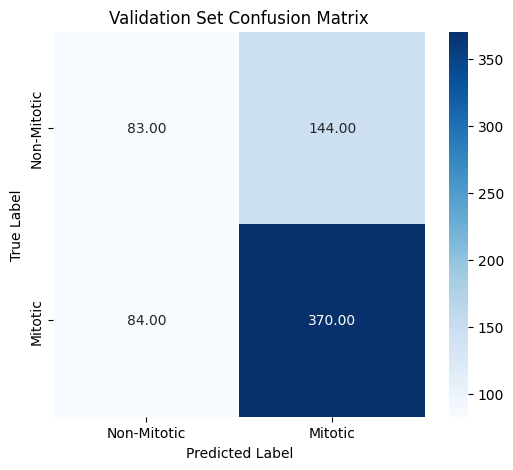

📊 Test Set Metrics:
  Precision: 0.3809
  Recall:    0.2420
  F1-score:  0.2960
  mAP@50:    0.2526
  mAP@50-95: 0.1718
  Accuracy:  0.6601

Confusion Matrix (raw values):
[[       2903        2266]
 [       5605       12380]]


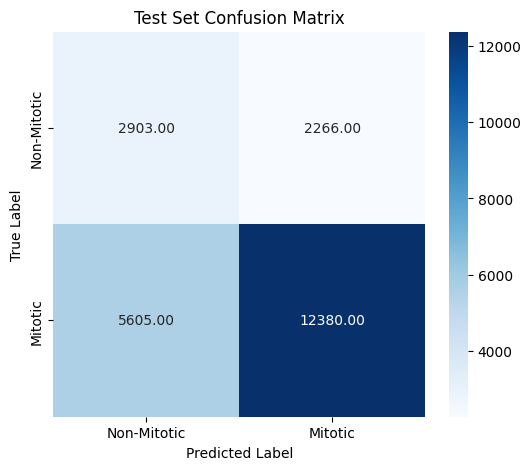

In [9]:
# Load the trained model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Evaluate on validation set
metrics_val = model.val(
    data='/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/data.yaml',
    split='val'
)

# Evaluate on test set
metrics_test = model.val(
    data='/content/drive/MyDrive/MIDOG_Challenge_2022_png/all_tiles_breast_to_multi/data.yaml',
    split='test'
)

# Function to serialize DetMetrics object
def serialize_metrics(metrics):
    serialized = {
        'metrics/precision(B)': metrics.box.mp.tolist() if hasattr(metrics.box.mp, 'tolist') else [float(metrics.box.mp)],
        'metrics/recall(B)': metrics.box.mr.tolist() if hasattr(metrics.box.mr, 'tolist') else [float(metrics.box.mr)],
        'metrics/mAP50(B)': metrics.box.map50.tolist() if hasattr(metrics.box.map50, 'tolist') else [float(metrics.box.map50)],
        'metrics/mAP50-95(B)': metrics.box.map.tolist() if hasattr(metrics.box.map, 'tolist') else [float(metrics.box.map)],
        'confusion_matrix': metrics.confusion_matrix.matrix.tolist() if metrics.confusion_matrix is not None else None
    }
    return serialized

# Save JSON results
os.makedirs('/content/runs/detect/val_eval_breast_to_multi', exist_ok=True)
os.makedirs('/content/runs/detect/test_eval_breast_to_multi', exist_ok=True)

with open('/content/runs/detect/val_eval_breast_to_multi/results.json', 'w') as f:
    json.dump(serialize_metrics(metrics_val), f)

with open('/content/runs/detect/test_eval_breast_to_multi/results.json', 'w') as f:
    json.dump(serialize_metrics(metrics_test), f)

# Print and plot confusion matrix
print_and_plot_confusion_matrix('/content/runs/detect/val_eval_breast_to_multi/results.json', split_name='Validation')
print_and_plot_confusion_matrix('/content/runs/detect/test_eval_breast_to_multi/results.json', split_name='Test')

## Visualize Training Loss and Validation Metrics

Columns found in results.csv: Index(['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


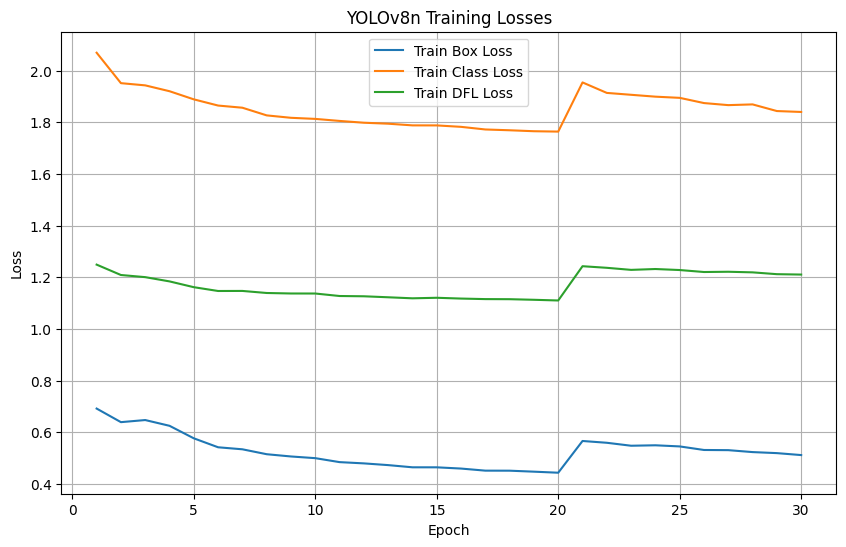

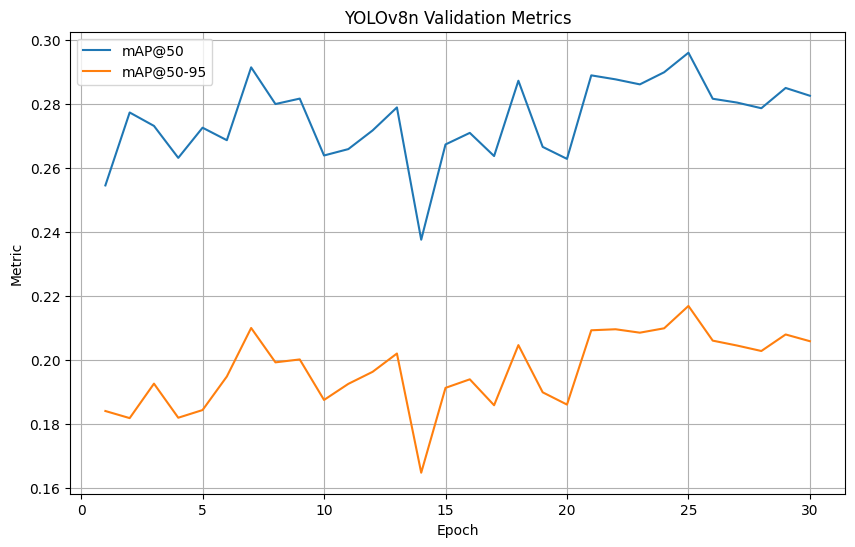

In [10]:
# Path to YOLO training logs
results_csv = '/content/runs/detect/train/results.csv'

# Load the results.csv
results_df = pd.read_csv(results_csv)
print("Columns found in results.csv:", results_df.columns)

# Plot training loss curves
plt.figure(figsize=(10, 6))
plt.plot(results_df['epoch'], results_df['train/box_loss'], label='Train Box Loss')
plt.plot(results_df['epoch'], results_df['train/cls_loss'], label='Train Class Loss')
plt.plot(results_df['epoch'], results_df['train/dfl_loss'], label='Train DFL Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('YOLOv8n Training Losses')
plt.legend()
plt.grid(True)
plt.show()

# Plot validation metrics
plt.figure(figsize=(10, 6))
plt.plot(results_df['epoch'], results_df['metrics/mAP50(B)'], label='mAP@50')
plt.plot(results_df['epoch'], results_df['metrics/mAP50-95(B)'], label='mAP@50-95')
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.title('YOLOv8n Validation Metrics')
plt.legend()
plt.grid(True)
plt.show()